In [1]:
import pandas as pd
import numpy as np
import os
import glob
from collections import defaultdict

# --- Directory Configuration ---
base_path = r"C:\Users\ML\Desktop\Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions"

# Note: We keep the same folders_path as they contain the sub-files for Inner/Outer
folders_path = [
    os.path.join(base_path, "3-Phase-current-0.7mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-0.9mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.1mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.3mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.5mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.7mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-12-4mm-broken-rotor-bar-fault"),
    os.path.join(base_path, "3-Phase-current-healthy-motor")
]

# --- Configuration Parameters ---
num_cols = 1000
current_cols = [' Current-A', ' Current-B', ' Current-C']

# --- Global lists to track issues ---
missing_files = []
insufficient_data_files = []
missing_column_files = []

def process_file_for_labeling(filename, label, num_cols=1000, current_cols=[' Current-A',' Current-B',' Current-C']):
    # (Same as your original function - no changes needed here)
    try:
        df = pd.read_csv(filename, low_memory=False)
    except Exception:
        return None

    all_rows = []
    for col_name in current_cols:
        if col_name not in df.columns: return None
        data = df[col_name].values
        n_complete_rows = len(data) // num_cols
        if n_complete_rows == 0: return None
        data = data[:n_complete_rows * num_cols]
        reshaped = data.reshape(n_complete_rows, num_cols)
        df_segment = pd.DataFrame(reshaped, columns=[f'Feature {i+1}' for i in range(num_cols)])
        all_rows.append(df_segment)

    final_df = pd.concat(all_rows, ignore_index=True)
    final_df['Status'] = label
    return final_df

# --- Process all files dynamically with 14-class logic ---
all_processed_dfs = []
file_tracking_summary = defaultdict(int)

print("--- Starting Data Discovery and Processing (14 Classes) ---")

for folder_path in folders_path:
    folder_name = os.path.basename(folder_path)
    file_list = glob.glob(os.path.join(folder_path, '*.csv'))

    for filename in file_list:
        base_file = os.path.basename(filename).lower()
        
        # 1. Logic for Healthy and Broken Rotor Bar
        if "healthy" in folder_name.lower():
            label = "Healthy"
        elif "broken-rotor" in folder_name.lower():
            label = "Broken Rotor Bar"
        
        # 2. Logic for 12 Bearing Classes (6 sizes x 2 locations)
        else:
            # Extract size (e.g., 0.7mm) from folder name
            size_str = folder_name.split('-')[3] 
            
            # Determine if Inner or Outer from filename
            if "inner" in base_file:
                label = f"Inner Race {size_str}"
            elif "outer" in base_file:
                label = f"Outer Race {size_str}"
            else:
                label = f"Other Bearing Fault {size_str}"

        # Process the file with the new label
        df_processed = process_file_for_labeling(filename, label)
        if df_processed is not None:
            all_processed_dfs.append(df_processed)
            file_tracking_summary[label] += 1

# --- Final Merge and Shuffle ---
if all_processed_dfs:
    df_final_merged = pd.concat(all_processed_dfs, ignore_index=True)
    df_shuffled = df_final_merged.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print("\n--- Processing Complete ---")
    print(f"Total rows: {len(df_shuffled)}")
    print("\nClass Distribution:")
    for lbl, count in file_tracking_summary.items():
        print(f"- {lbl}: {count} files")
    
    # Save
    output_path = r"C:\Processed_Motor_Data\binary_motor_data.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df_shuffled.to_csv(output_path, index=False)
else:
    print("No data processed.")

--- Starting Data Discovery and Processing (14 Classes) ---

--- Processing Complete ---
Total rows: 15510

Class Distribution:
- Inner Race 0.7mm: 3 files
- Outer Race 0.7mm: 3 files
- Inner Race 0.9mm: 3 files
- Outer Race 0.9mm: 3 files
- Inner Race 1.1mm: 3 files
- Outer Race 1.1mm: 3 files
- Inner Race 1.3mm: 3 files
- Outer Race 1.3mm: 3 files
- Inner Race 1.5mm: 3 files
- Outer Race 1.5mm: 3 files
- Inner Race 1.7mm: 3 files
- Outer Race 1.7mm: 3 files
- Broken Rotor Bar: 2 files
- Healthy: 1 files


In [2]:
output_dir = r"C:\Processed_Motor_Data"
output_filename = 'binary_motor_data.csv' 
full_output_path = os.path.join(output_dir, output_filename)
df = pd.read_csv(full_output_path)
print(f"Successfully loaded '{output_filename}' into DataFrame 'df'.")

print("Shape of data")
print(f"DataFrame shape: {df.shape}")

Successfully loaded 'binary_motor_data.csv' into DataFrame 'df'.
Shape of data
DataFrame shape: (15510, 1001)


In [5]:
df=df.dropna()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc)

# 1.1 Sampling and Cleaning
#df_sample = df.sample(n=10000, random_state=42).dropna()

# Binary target: Healthy = 1, All others = 0
df['Target'] = df['Status'].apply(
    lambda x: 1 if x.lower() == 'healthy' else 0
)

# Select feature columns explicitly (everything except Status & Target)
feature_cols = df.columns.difference(['Status', 'Target'])

X_raw = df[feature_cols]
y_raw = df['Target']

X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [17]:
bin_model = LogisticRegression(
    max_iter=1000
)

bin_model.fit(X_train, y_train_labels)
y_pred_bin = bin_model.predict(X_test)
print("Binary Classification Accuracy:", accuracy_score(y_test_labels, y_pred_bin))

Binary Classification Accuracy: 0.9764592067075137


In [19]:
# 1. Generate Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_bin)

# Handle case when model predicts only one class
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

# 2. Calculate Metrics
accuracy = accuracy_score(y_test_labels, y_pred_bin)
precision = precision_score(y_test_labels, y_pred_bin, zero_division=0)
recall = recall_score(y_test_labels, y_pred_bin, zero_division=0)   # Sensitivity
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
f1 = f1_score(y_test_labels, y_pred_bin, zero_division=0)

# 3. Print Metrics
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity    : {specificity:.4f}")
print(f"F1 Score       : {f1:.4f}")


Accuracy       : 0.9765
Precision      : 0.0000
Recall (Sensitivity): 0.0000
Specificity    : 1.0000
F1 Score       : 0.0000


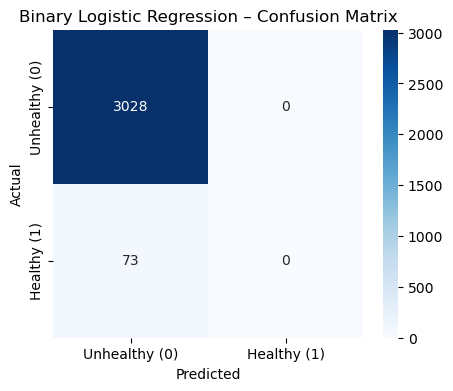

In [21]:
# 4. Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Unhealthy (0)', 'Healthy (1)'],
    yticklabels=['Unhealthy (0)', 'Healthy (1)']
)
plt.title('Binary Logistic Regression – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


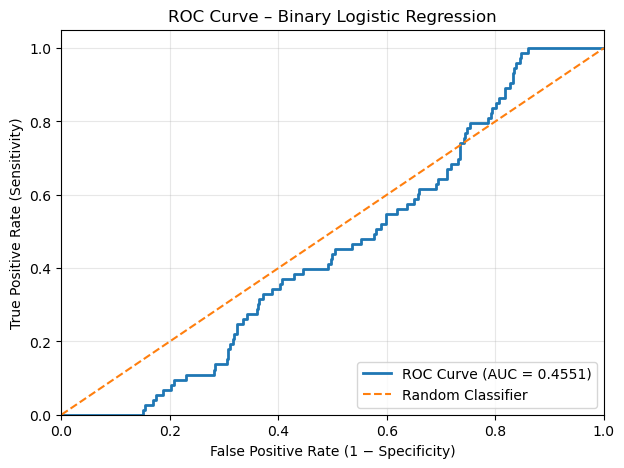

Binary AUC Score: 0.4551


In [29]:
# 1. Get predicted probabilities for the positive class (Healthy = 1)
y_probs = bin_model.predict_proba(X_test)[:, 1]

# 2. Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_labels, y_probs, pos_label=1)

# 3. Compute AUC
roc_auc = auc(fpr, tpr)

# 4. Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 − Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve – Binary Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Binary AUC Score: {roc_auc:.4f}")


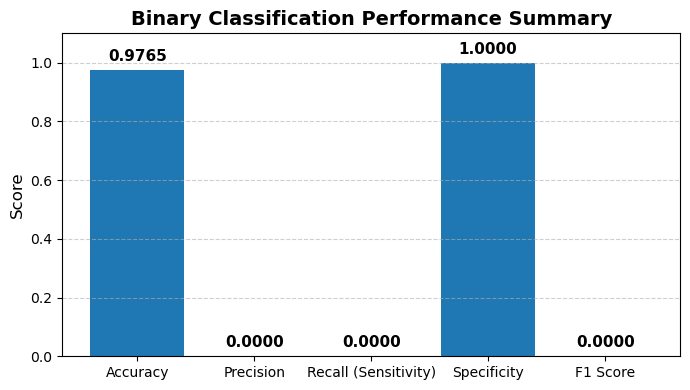

In [31]:
# 1. Prepare data for the plot
metrics_names = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1 Score']
metrics_values = [accuracy, precision, recall, specificity, f1]

# 2. Create the bar plot
plt.figure(figsize=(7,4))
bars = plt.bar(metrics_names, metrics_values)

# 3. Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# 4. Customize the plot
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.title('Binary Classification Performance Summary', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Display
plt.tight_layout()
plt.show()


In [27]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Labeling on 'Status' column
le = LabelEncoder()
df['Status_Encoded'] = le.fit_transform(df['Status'])

# Step 2: Feature and Label Selection
# We exclude the original 'Status', 'Target', and the new 'Status_Encoded' from features
feature_cols = df.columns.difference(['Status', 'Target', 'Status_Encoded'])
X_multi = df[feature_cols]
y_multi = df['Status_Encoded']

# Step 3: Train-Test Split (using 30% for testing)
X_train_m_raw, X_test_m_raw, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

# Step 4: Feature Scaling (Standardization)
scaler_m = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m_raw)
X_test_m = scaler_m.transform(X_test_m_raw)

# Step 5: Perform Code (Train and Predict)
multi_model = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

print("--- Multi-Class Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_m):.4f}")


--- Multi-Class Logistic Regression Results ---
Accuracy: 0.0348


In [33]:
# Standard Metrics
accuracy = accuracy_score(y_test_m, y_pred_m)
precision = precision_score(y_test_m, y_pred_m, average='weighted')
recall = recall_score(y_test_m, y_pred_m, average='weighted') 
f1 = f1_score(y_test_m, y_pred_m, average='weighted')

# Custom Multiclass Specificity Function
def get_multiclass_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for i in range(len(cm)):
        # TN: All elements except row i and column i
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        # FP: Sum of column i minus the diagonal element (actual i)
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    return np.mean(specificities)

specificity = get_multiclass_specificity(y_test_m, y_pred_m)

# Display Final Results
print("--- Multi-Class Logistic Regression Performance ---")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1:.4f}")

--- Multi-Class Logistic Regression Performance ---
Accuracy:    0.0348
Precision:   0.0398
Sensitivity: 0.0348
Specificity: 0.9253
F1 Score:    0.0314


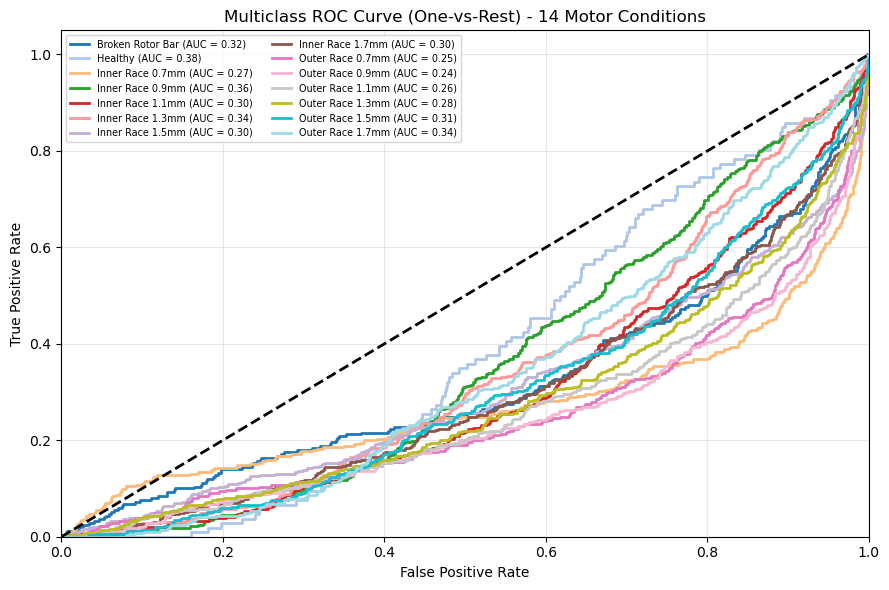

In [46]:
# ==========================================
# 4. MULTICLASS ROC CURVE VISUALIZATION
# ==========================================

y_score = multi_model.predict_proba(X_test_m)
# Binarize labels for One-vs-Rest ROC
y_test_binarized = label_binarize(y_test_m, classes=range(14))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(14):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
plt.figure(figsize=(9, 6))
colors = plt.colormaps['tab20'](np.linspace(0, 1, 14))

for i, color in zip(range(14), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest) - 14 Motor Conditions')
plt.legend(loc="upper left", fontsize='x-small', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

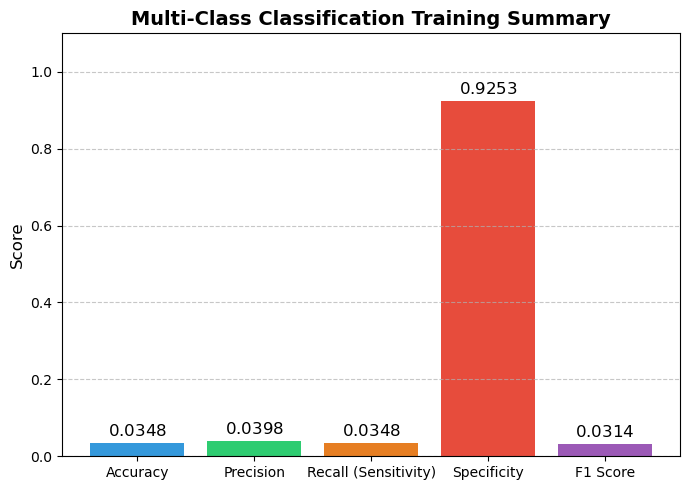

In [48]:
# 1. Prepare data for the plot
metrics_names = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1 Score']
metrics_values = [accuracy, precision, recall, specificity, f1]

# 2. Create the bar plot
plt.figure(figsize=(7,5))
bars = plt.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6'])

# 3. Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'${yval:.4f}$', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. Customizing the plot
plt.ylim(0, 1.1)  # Metrics are between 0 and 1
plt.ylabel('Score', fontsize=12)
plt.title('Multi-Class Classification Training Summary', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and show
plt.tight_layout()
plt.show()